<a href="https://colab.research.google.com/github/armandoordonez/eda_couse/blob/main/EDA_Guia_Automoviles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos (EDA) — Guía paso a paso

## Caso: Análisis de precios de automóviles

---

Este cuaderno constituye una **guía metodológica completa** que reproduce, paso a paso, el flujo general de trabajo presentado en clase. El objetivo pedagógico es que el estudiante comprenda no solamente *cómo* se ejecuta cada instrucción, sino *por qué* se ejecuta y *qué decisión de negocio* respalda cada una de ellas.

El flujo que seguiremos es el siguiente:

> **Pregunta SMART + Hipótesis → Diccionario de datos → Visión general → Limpieza → Análisis univariado → Análisis bivariado → Conclusiones**

En cada sección se indicará de manera explícita a qué etapa del flujo corresponde, con el fin de mantener la trazabilidad entre la teoría vista en la presentación y su implementación práctica.

---
# 1. El problema de negocio y la Pregunta SMART

> *Etapa del flujo: **Pregunta SMART + Hipótesis***

Antes de escribir una sola línea de código, todo análisis exploratorio riguroso debe partir de un **problema de negocio claramente delimitado**. Sin una pregunta que oriente el trabajo, el analista corre el riesgo de producir estadísticos y gráficos que, aunque técnicamente correctos, no aportan valor a la toma de decisiones.

## 1.1. Contexto del negocio

Suponga que trabajamos para una **aseguradora de vehículos** que desea mejorar la forma en que fija las primas de sus pólizas. La compañía dispone de un conjunto de datos con las características técnicas de 205 automóviles, su nivel de riesgo asignado por actuarios, la pérdida promedio anual histórica y su precio de mercado.

La dirección comercial plantea la siguiente inquietud:

> *"¿Qué características de un vehículo permiten explicar y anticipar su precio de mercado?"*

Conocer los factores que determinan el precio resulta estratégico, pues el precio del vehículo es una de las variables que la compañía utiliza para dimensionar el valor asegurado y, en consecuencia, la prima.

## 1.2. Formulación de la Pregunta SMART

Una pregunta **SMART** es aquella que resulta **e**S**pecífica, **M**edible, **A**lcanzable, **R**elevante y acotada en el **T**iempo (por sus siglas en inglés). Reformulamos la inquietud del negocio en estos términos:

> **Pregunta SMART:** *"¿Es posible explicar la variación del **precio** de los automóviles del portafolio a partir de sus atributos técnicos (tamaño del motor, potencia, peso, consumo de combustible, tipo de tracción, entre otros), utilizando el conjunto de datos histórico disponible de 205 vehículos?"*

## 1.3. Hipótesis de trabajo

A partir del conocimiento del dominio, planteamos hipótesis que el análisis deberá confirmar o refutar:

- **H1:** Existe una relación **positiva** entre el tamaño del motor (o la potencia) y el precio.
- **H2:** Los vehículos más **pesados** tienden a ser más costosos.
- **H3:** Un mayor **consumo de combustible** (menor eficiencia) se asocia con vehículos de mayor precio, por tratarse típicamente de gamas superiores.
- **H4:** El **fabricante** y el tipo de **tracción** introducen diferencias sistemáticas de precio.

El propósito del EDA será determinar si el conjunto de datos disponible **contiene información suficiente y de calidad** para responder la pregunta SMART y evaluar estas hipótesis.

---
# 2. Carga del conjunto de datos

Comenzamos importando las librerías que utilizaremos a lo largo de todo el cuaderno. Se recomienda concentrar las importaciones al inicio para facilitar la lectura y el mantenimiento del código.

- **pandas**: manipulación de datos tabulares.
- **numpy**: operaciones numéricas y manejo del marcador de valores perdidos `NaN`.
- **matplotlib** y **seaborn**: construcción de las visualizaciones que sustentan el análisis.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética general de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

# Evita que pandas trunque columnas al visualizar
pd.set_option("display.max_columns", None)

El conjunto de datos original **no incluye una fila de encabezados**, por lo que debemos proporcionar manualmente la lista de nombres de las columnas. Esta lista constituye, de hecho, el primer insumo para elaborar el **diccionario de datos** de la siguiente sección.

Los nombres han sido traducidos al español y normalizados (minúsculas, sin espacios) para facilitar su manipulación posterior.

In [2]:
# Ubicación del archivo de datos (repositorio público)
filename = "https://raw.githubusercontent.com/lvmeninnovations/datasets/main/crispdm/auto.csv"

# Nombres de los 26 atributos, en el orden en que aparecen en el archivo
headers = [
    "factor-riesgo", "perdida-promedio-anual", "fabricante", "tipo-combustible",
    "aspiracion", "num-puertas", "estilo-carroceria", "traccion", "ubicacion-motor",
    "distancia-entre-ejes", "longitud", "anchura", "altura", "peso-vacio",
    "tipo-motor", "num-cilindros", "tamano-motor", "sistema-combustible",
    "calibre", "carrera", "relacion-compresion", "caballos-fuerza",
    "pico-rpm", "millas_por_galon_ciudad", "millas_por_galon_carretera", "precio"
]

# Lectura del archivo CSV asignando los encabezados definidos
df = pd.read_csv(filename, names=headers)

print("El conjunto de datos se cargó correctamente.")
print(f"Dimensiones: {df.shape[0]} filas (vehículos) y {df.shape[1]} columnas (atributos).")

El conjunto de datos se cargó correctamente.
Dimensiones: 205 filas (vehículos) y 26 columnas (atributos).


---
# 3. Diccionario de datos

> *Etapa del flujo: **Diccionario de datos***

El diccionario de datos es el documento que describe el **significado, el tipo y la relevancia esperada** de cada variable. Es una pieza fundamental del EDA porque nos permite interpretar correctamente los datos y detectar de antemano qué variables son candidatas a responder nuestra pregunta de negocio.

Siguiendo la estructura vista en clase, para cada variable documentamos cuatro elementos:

- **Variable:** nombre del atributo.
- **Tipo:** categórico, numérico (continuo/discreto), booleano, etc.
- **Contexto:** información del dominio que ayuda a entender el espacio semántico de la variable. En nuestro caso, el contexto es **técnico-automotriz**.
- **Expectativa:** qué tan relevante creemos que es la variable respecto a nuestra tarea (predecir el precio). Usamos una escala **Alta / Media / Baja**.

## 3.1. Diccionario del conjunto de datos de automóviles

In [3]:
# Construimos el diccionario de datos como un DataFrame para poder visualizarlo con orden.
diccionario = pd.DataFrame([
    ["factor-riesgo",              "Numérico (discreto)", "Nivel de riesgo actuarial asignado al vehículo (-3 muy seguro a +3 muy riesgoso).", "Media"],
    ["perdida-promedio-anual",     "Numérico (continuo)", "Pago promedio anual por pérdidas asociado al vehículo (indicador de siniestralidad).", "Media"],
    ["fabricante",                 "Categórico",          "Marca del automóvil (alfa-romero, audi, bmw, etc.).", "Alta"],
    ["tipo-combustible",           "Categórico",          "Tipo de combustible: gas o diesel.", "Media"],
    ["aspiracion",                 "Categórico",          "Sistema de aspiración del motor: estándar (std) o turbo.", "Media"],
    ["num-puertas",                "Categórico",          "Número de puertas: two o four.", "Baja"],
    ["estilo-carroceria",          "Categórico",          "Tipo de carrocería: sedan, hatchback, wagon, hardtop, convertible.", "Media"],
    ["traccion",                   "Categórico",          "Tipo de tracción: rwd (trasera), fwd (delantera), 4wd (integral).", "Alta"],
    ["ubicacion-motor",            "Categórico",          "Ubicación del motor: front (delantero) o rear (trasero).", "Baja"],
    ["distancia-entre-ejes",       "Numérico (continuo)", "Distancia entre ejes delantero y trasero (pulgadas).", "Media"],
    ["longitud",                   "Numérico (continuo)", "Longitud total del vehículo.", "Media"],
    ["anchura",                    "Numérico (continuo)", "Anchura del vehículo.", "Media"],
    ["altura",                     "Numérico (continuo)", "Altura del vehículo.", "Baja"],
    ["peso-vacio",                 "Numérico (continuo)", "Peso del vehículo en vacío (libras).", "Alta"],
    ["tipo-motor",                 "Categórico",          "Configuración del motor (dohc, ohc, ohcv, rotor, etc.).", "Media"],
    ["num-cilindros",              "Categórico",          "Número de cilindros expresado en texto (four, six, ...).", "Alta"],
    ["tamano-motor",               "Numérico (continuo)", "Cilindrada / tamaño del motor.", "Alta"],
    ["sistema-combustible",        "Categórico",          "Sistema de alimentación de combustible (mpfi, 2bbl, idi, ...).", "Media"],
    ["calibre",                    "Numérico (continuo)", "Diámetro del cilindro (bore).", "Media"],
    ["carrera",                    "Numérico (continuo)", "Recorrido del pistón (stroke).", "Media"],
    ["relacion-compresion",        "Numérico (continuo)", "Relación de compresión del motor.", "Media"],
    ["caballos-fuerza",            "Numérico (continuo)", "Potencia del motor (HP).", "Alta"],
    ["pico-rpm",                   "Numérico (continuo)", "Revoluciones por minuto a las que se alcanza la potencia máxima.", "Media"],
    ["millas_por_galon_ciudad",    "Numérico (continuo)", "Consumo de combustible en ciudad (mpg).", "Alta"],
    ["millas_por_galon_carretera", "Numérico (continuo)", "Consumo de combustible en carretera (mpg).", "Alta"],
    ["precio",                     "Numérico (continuo)", "Precio de mercado del vehículo. VARIABLE OBJETIVO.", "Objetivo"],
], columns=["Variable", "Tipo", "Contexto", "Expectativa"])

diccionario

,Variable,Tipo,Contexto,Expectativa
0,factor-riesgo,Numérico (discreto),Nivel de riesgo actuarial asignado al vehículo...,Media
1,perdida-promedio-anual,Numérico (continuo),Pago promedio anual por pérdidas asociado al v...,Media
2,fabricante,Categórico,"Marca del automóvil (alfa-romero, audi, bmw, e...",Alta
3,tipo-combustible,Categórico,Tipo de combustible: gas o diesel.,Media
4,aspiracion,Categórico,Sistema de aspiración del motor: estándar (std...,Media
5,num-puertas,Categórico,Número de puertas: two o four.,Baja
6,estilo-carroceria,Categórico,"Tipo de carrocería: sedan, hatchback, wagon, h...",Media
7,traccion,Categórico,"Tipo de tracción: rwd (trasera), fwd (delanter...",Alta
8,ubicacion-motor,Categórico,Ubicación del motor: front (delantero) o rear ...,Baja
9,distancia-entre-ejes,Numérico (continuo),Distancia entre ejes delantero y trasero (pulg...,Media


**Lectura del diccionario.** La columna **precio** es nuestra variable **objetivo**: es la que deseamos explicar. Las variables marcadas con expectativa **Alta** (tamaño del motor, potencia, peso, cilindros, consumo, fabricante y tracción) son las primeras candidatas a explicar el precio, y por tanto recibirán especial atención durante el análisis bivariado. Este ejercicio de anticipación es valioso porque nos permite contrastar, al final, nuestras **expectativas iniciales** con la **evidencia empírica**.

---
# 4. Visión general del conjunto de datos

> *Etapa del flujo: **Visión general (formato, nombres, tipos, unidades, columnas redundantes)***

Antes de entrar al detalle de cada variable, obtenemos una **fotografía global** del dataset. En esta etapa nos interesa verificar, tal como indica la presentación:

- El **formato** general de los datos.
- Los **nombres** de las columnas (nomenclatura).
- Los **tipos de datos** de cada columna.
- Las **unidades de medida**.
- La existencia de **columnas redundantes o no útiles** (identificadores, información personal, *data leakage*).
- La necesidad de **crear nuevas columnas**.

## 4.1. Primeras filas del conjunto de datos

In [4]:
# El método head() muestra las primeras filas y permite una inspección visual rápida.
df.head()

,factor-riesgo,perdida-promedio-anual,fabricante,tipo-combustible,aspiracion,num-puertas,estilo-carroceria,traccion,ubicacion-motor,distancia-entre-ejes,longitud,anchura,altura,peso-vacio,tipo-motor,num-cilindros,tamano-motor,sistema-combustible,calibre,carrera,relacion-compresion,caballos-fuerza,pico-rpm,millas_por_galon_ciudad,millas_por_galon_carretera,precio
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


**Observación importante.** Al inspeccionar las primeras filas se aprecian **signos de interrogación `?`** en algunas celdas. Estos símbolos son la forma en que el proveedor de los datos marcó los **valores perdidos**. Los abordaremos en la etapa de limpieza; por ahora sólo dejamos constancia de su presencia.

## 4.2. Estructura, tipos de datos y memoria

In [5]:
# info() resume el número de registros no nulos y el tipo de dato de cada columna.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   factor-riesgo               205 non-null    int64  
 1   perdida-promedio-anual      205 non-null    object 
 2   fabricante                  205 non-null    object 
 3   tipo-combustible            205 non-null    object 
 4   aspiracion                  205 non-null    object 
 5   num-puertas                 205 non-null    object 
 6   estilo-carroceria           205 non-null    object 
 7   traccion                    205 non-null    object 
 8   ubicacion-motor             205 non-null    object 
 9   distancia-entre-ejes        205 non-null    float64
 10  longitud                    205 non-null    float64
 11  anchura                     205 non-null    float64
 12  altura                      205 non-null    float64
 13  peso-vacio                  205 non

**Análisis de los tipos de datos.** El resultado anterior revela un problema frecuente en la práctica: varias columnas que **conceptualmente son numéricas** aparecen almacenadas como texto (`object`). Es el caso de `perdida-promedio-anual`, `calibre`, `carrera`, `caballos-fuerza`, `pico-rpm` y `precio`.

La causa es precisamente la presencia de los signos `?`: al mezclar números con texto en una misma columna, pandas la interpreta en su totalidad como texto. Corregir estos tipos será uno de los objetivos de la limpieza, pues **no es posible calcular estadísticos ni graficar distribuciones sobre variables almacenadas como texto**.

## 4.3. Dimensiones, columnas y valores únicos

In [6]:
# Número de filas y columnas
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("-" * 60)

# Cantidad de valores distintos por columna: ayuda a distinguir
# variables categóricas (pocos valores) de continuas (muchos valores).
df.nunique().sort_values()

Filas: 205 | Columnas: 26
------------------------------------------------------------


,0
tipo-combustible,2
aspiracion,2
ubicacion-motor,2
num-puertas,3
traccion,3
estilo-carroceria,5
factor-riesgo,6
num-cilindros,7
tipo-motor,7
sistema-combustible,8


**Sobre columnas redundantes, identificadores y *data leakage*.** La presentación advierte que en esta etapa debemos detectar columnas que conviene descartar:

- **Identificadores / información personal:** este conjunto de datos **no contiene** ni un identificador único de fila ni datos personales, por lo que no hay que eliminar columnas por este motivo.
- ***Data leakage* (fuga de información):** ocurre cuando una variable contiene información que no estaría disponible en el momento de la predicción, o que es una consecuencia directa de la variable objetivo. En nuestro caso, las columnas `factor-riesgo` y `perdida-promedio-anual` son asignadas por actuarios y podrían, en un modelo posterior, introducir fuga si dependieran del precio. Las conservamos por ahora, pero **queda anotado el riesgo** para la etapa de modelado.

## 4.4. Estadísticos descriptivos preliminares

In [7]:
# describe() sobre las columnas ya numéricas ofrece un primer panorama
# de rangos, medias y dispersión. (Las columnas con "?" aún no aparecen.)
df.describe()

,factor-riesgo,distancia-entre-ejes,longitud,anchura,altura,peso-vacio,tamano-motor,relacion-compresion,millas_por_galon_ciudad,millas_por_galon_carretera
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


---
# 5. Limpieza y preparación de los datos

> *Etapa del flujo: preparación previa al análisis (valores perdidos, formato)*

La calidad del análisis depende directamente de la calidad de los datos. En esta sección abordamos los tres problemas identificados en la visión general, siguiendo el procedimiento estándar:

1. Identificar los valores perdidos.
2. Decidir cómo tratar cada valor perdido.
3. Corregir el formato (tipo) de los datos.

> **Advertencia profesional.** No todos los valores atípicos o sospechosos deben "corregirse". Algunos son genuinos desde el punto de vista del negocio. En un entorno real, conviene validar con el equipo de ingeniería de datos antes de modificar el conjunto original.

## 5.1. Identificación de valores perdidos

### Paso 1 — Convertir los `?` en `NaN`

Para que pandas reconozca los valores perdidos, reemplazamos el marcador `?` por el valor estándar `NaN` (*Not a Number*) de numpy.

In [8]:
# Reemplazamos el marcador "?" por NaN en todo el DataFrame.
df.replace("?", np.nan, inplace=True)

df.head()

,factor-riesgo,perdida-promedio-anual,fabricante,tipo-combustible,aspiracion,num-puertas,estilo-carroceria,traccion,ubicacion-motor,distancia-entre-ejes,longitud,anchura,altura,peso-vacio,tipo-motor,num-cilindros,tamano-motor,sistema-combustible,calibre,carrera,relacion-compresion,caballos-fuerza,pico-rpm,millas_por_galon_ciudad,millas_por_galon_carretera,precio
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Paso 2 — Cuantificar los valores perdidos por columna

El método `.isnull()` devuelve una matriz booleana (`True` = valor perdido). Encadenándolo con `.sum()` obtenemos el conteo de faltantes por columna de manera directa.

In [9]:
# Conteo de valores perdidos por columna, mostrando sólo las columnas afectadas.
faltantes = df.isnull().sum()
faltantes[faltantes > 0].sort_values(ascending=False)

,0
perdida-promedio-anual,41
calibre,4
carrera,4
precio,4
num-puertas,2
caballos-fuerza,2
pico-rpm,2


**Diagnóstico de faltantes.** Siete columnas presentan valores perdidos. Conviene expresarlos también como **porcentaje**, pues la proporción de faltantes influye en la estrategia de tratamiento.

In [10]:
# Porcentaje de valores perdidos por columna afectada.
porcentaje = (df.isnull().sum() / len(df) * 100).round(2)
porcentaje[porcentaje > 0].sort_values(ascending=False)

,0
perdida-promedio-anual,20.00
calibre,1.95
carrera,1.95
precio,1.95
num-puertas,0.98
caballos-fuerza,0.98
pico-rpm,0.98


## 5.2. Tratamiento de los valores perdidos

Ante los valores perdidos disponemos de dos grandes estrategias: **eliminar** (filas o columnas) o **reemplazar/imputar** (por la media, por la moda o mediante otro criterio). La decisión se toma **columna por columna**, en función del significado de la variable y de la cantidad de faltantes.

Ninguna columna está lo bastante vacía como para eliminarla por completo, de modo que aplicaremos el criterio más razonable a cada caso:

| Columna | Faltantes | Estrategia | Justificación |
|---|---|---|---|
| `perdida-promedio-anual` | 41 | Imputar por la **media** | Variable continua; la media conserva el promedio. |
| `calibre`, `carrera` | 4 | Imputar por la **media** | Variables continuas del motor. |
| `caballos-fuerza`, `pico-rpm` | 2 | Imputar por la **media** | Variables continuas del motor. |
| `num-puertas` | 2 | Imputar por la **moda** | Variable **categórica**: la media no aplica. |
| `precio` | 4 | **Eliminar la fila** | Es la variable **objetivo**: sin precio, la fila no sirve. |

### 5.2.1. Imputación por la media (variables continuas)

Calculamos primero el promedio de cada columna (forzando su conversión a `float`, ya que aún son texto) y luego sustituimos los `NaN` por ese valor.

In [11]:
# Columnas continuas que imputaremos con la media.
cols_media = ["perdida-promedio-anual", "calibre", "carrera", "caballos-fuerza", "pico-rpm"]

for col in cols_media:
    promedio = df[col].astype("float").mean()
    # Asignación directa: forma robusta y recomendada en versiones actuales de pandas.
    df[col] = df[col].astype("float").fillna(promedio)
    print(f"'{col}': NaN reemplazados por la media = {round(promedio, 2)}")

'perdida-promedio-anual': NaN reemplazados por la media = 122.0
'calibre': NaN reemplazados por la media = 3.33
'carrera': NaN reemplazados por la media = 3.26
'caballos-fuerza': NaN reemplazados por la media = 104.26
'pico-rpm': NaN reemplazados por la media = 5125.37


### 5.2.2. Imputación por la frecuencia / moda (variable categórica)

La columna `num-puertas` es categórica, por lo que la media carece de sentido. Reemplazamos los faltantes por el valor **más frecuente** (la moda). Primero verificamos cuál es.

In [12]:
# Frecuencia de cada categoría en num-puertas
print(df["num-puertas"].value_counts())

# Valor más frecuente (moda) calculado automáticamente
moda_puertas = df["num-puertas"].value_counts().idxmax()
print("\nValor más frecuente:", moda_puertas)

# Imputación por la moda (asignación directa)
df["num-puertas"] = df["num-puertas"].fillna(moda_puertas)

num-puertas
four    114
two      89
Name: count, dtype: int64

Valor más frecuente: four


### 5.2.3. Eliminación de filas (variable objetivo)

La columna `precio` es la variable que deseamos explicar. Una fila **sin precio** no aporta información para nuestro objetivo, de modo que la eliminamos por completo. Tras eliminar filas, es buena práctica **reindexar** el DataFrame.

In [13]:
# Eliminamos las filas cuyo precio es NaN.
df.dropna(subset=["precio"], axis=0, inplace=True)

# Reindexamos para que el índice quede continuo tras la eliminación.
df.reset_index(drop=True, inplace=True)

print("Filas restantes tras eliminar precios faltantes:", df.shape[0])

Filas restantes tras eliminar precios faltantes: 201


### Verificación: el dataset ya no tiene valores perdidos

In [14]:
# Confirmamos que no queda ningún valor perdido.
total_faltantes = df.isnull().sum().sum()
print("Total de valores perdidos en el dataset:", total_faltantes)
assert total_faltantes == 0, "Aún quedan valores perdidos."
print("El conjunto de datos está completo.")

Total de valores perdidos en el dataset: 0
El conjunto de datos está completo.


## 5.3. Corrección del formato de los datos

El último paso de la limpieza consiste en asegurar que **cada columna tenga el tipo de dato apropiado**. Las columnas que antes contenían `?` siguen almacenadas como texto (`object`) y deben convertirse a numéricas para poder analizarlas.

In [15]:
# Conversión de columnas al tipo numérico correcto.
df[["calibre", "carrera", "caballos-fuerza", "pico-rpm", "precio"]] = \
    df[["calibre", "carrera", "caballos-fuerza", "pico-rpm", "precio"]].astype("float")

df[["perdida-promedio-anual"]] = df[["perdida-promedio-anual"]].astype("int")

print("Tipos de datos corregidos:")
df.dtypes

Tipos de datos corregidos:


,0
factor-riesgo,int64
perdida-promedio-anual,int64
fabricante,object
tipo-combustible,object
aspiracion,object
num-puertas,object
estilo-carroceria,object
traccion,object
ubicacion-motor,object
distancia-entre-ejes,float64


## 5.4. Creación de nuevas columnas (estandarización de unidades)

La visión general contemplaba la posibilidad de **crear columnas nuevas** cuando sea útil. Las variables de consumo están en **millas por galón (mpg)**, un estándar poco usado fuera de EE. UU. Para facilitar la interpretación en mercados que emplean el sistema métrico, creamos su equivalente en **L/100 km** mediante la relación `L/100km = 235 / mpg`.

> Nota: un valor **alto** de mpg significa vehículo **eficiente**, mientras que un valor **alto** de L/100km significa vehículo **poco eficiente**. La interpretación se invierte.

In [16]:
# Creamos las columnas de consumo en L/100km a partir de las de mpg.
df["ciudad-L/100km"]    = 235 / df["millas_por_galon_ciudad"]
df["carretera-L/100km"] = 235 / df["millas_por_galon_carretera"]

df[["millas_por_galon_ciudad", "ciudad-L/100km",
    "millas_por_galon_carretera", "carretera-L/100km"]].head()

,millas_por_galon_ciudad,ciudad-L/100km,millas_por_galon_carretera,carretera-L/100km
0,21,11.190476,27,8.703704
1,21,11.190476,27,8.703704
2,19,12.368421,26,9.038462
3,24,9.791667,30,7.833333
4,18,13.055556,22,10.681818


Con esto concluye la etapa de limpieza. Disponemos ahora de un conjunto de datos **completo, con tipos correctos y unidades estandarizadas**, listo para el análisis exploratorio propiamente dicho.

---
# 6. Análisis univariado

> *Etapa del flujo: **Análisis univariado** — para cada variable: faltantes, outliers y distribución*

El análisis univariado estudia **una variable a la vez**. Su propósito es comprender, para cada atributo, su **distribución**, su **tendencia central**, su **dispersión** y la presencia de **valores atípicos (outliers)**. La presentación distingue el tratamiento según el tipo de variable:

- **Variables continuas:** examinamos faltantes, outliers y forma de la distribución (histogramas, boxplots).
- **Variables categóricas:** examinamos faltantes, categorías presentes y frecuencia de cada una (gráficos de barras).

Comenzamos separando las columnas por tipo para organizar el análisis.

In [17]:
# Clasificamos las columnas en numéricas y categóricas.
variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables NUMÉRICAS ({}):".format(len(variables_numericas)))
print(variables_numericas)
print("\nVariables CATEGÓRICAS ({}):".format(len(variables_categoricas)))
print(variables_categoricas)

Variables NUMÉRICAS (18):
['factor-riesgo', 'perdida-promedio-anual', 'distancia-entre-ejes', 'longitud', 'anchura', 'altura', 'peso-vacio', 'tamano-motor', 'calibre', 'carrera', 'relacion-compresion', 'caballos-fuerza', 'pico-rpm', 'millas_por_galon_ciudad', 'millas_por_galon_carretera', 'precio', 'ciudad-L/100km', 'carretera-L/100km']

Variables CATEGÓRICAS (10):
['fabricante', 'tipo-combustible', 'aspiracion', 'num-puertas', 'estilo-carroceria', 'traccion', 'ubicacion-motor', 'tipo-motor', 'num-cilindros', 'sistema-combustible']


## 6.1. La variable objetivo: `precio`

Iniciamos por la variable que deseamos explicar. Comprender su distribución es esencial: nos dice cómo se reparten los precios del portafolio y si presenta asimetría o valores extremos que puedan condicionar el análisis posterior.

count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: precio, dtype: float64


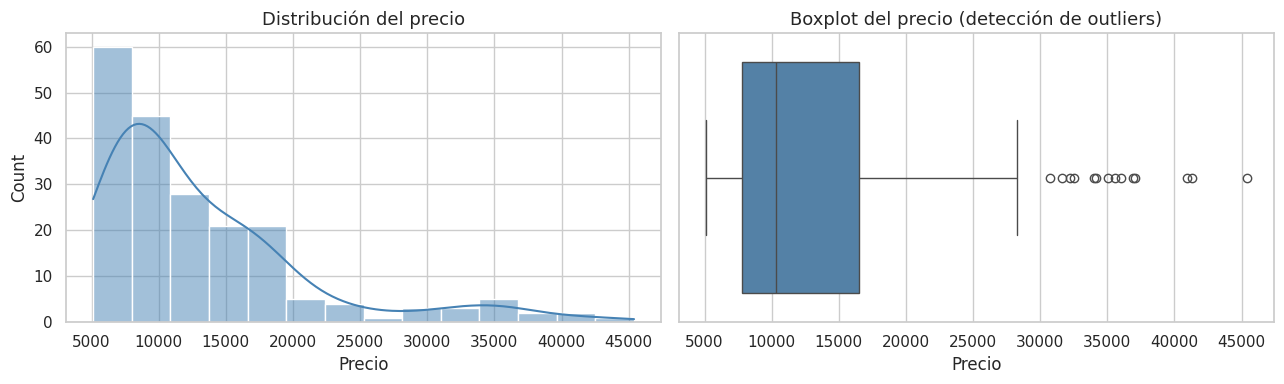

In [18]:
# Estadísticos descriptivos del precio
print(df["precio"].describe())

# Histograma + boxplot del precio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["precio"], kde=True, ax=ax1, color="steelblue")
ax1.set_title("Distribución del precio")
ax1.set_xlabel("Precio")

sns.boxplot(x=df["precio"], ax=ax2, color="steelblue")
ax2.set_title("Boxplot del precio (detección de outliers)")
ax2.set_xlabel("Precio")

plt.tight_layout()
plt.show()

**Interpretación.** La distribución del precio está **sesgada a la derecha**: la mayoría de los vehículos se concentran en precios bajos y medios, mientras que un pequeño grupo de vehículos de gama alta alcanza precios muy superiores. El boxplot confirma la presencia de **outliers en el extremo superior**. Este sesgo es habitual en variables de precio y deberá tenerse en cuenta al modelar (por ejemplo, aplicando transformaciones logarítmicas).

## 6.2. Variables numéricas continuas

Para las variables continuas de mayor **expectativa** según el diccionario (`tamano-motor`, `caballos-fuerza`, `peso-vacio`, `millas_por_galon_ciudad`), analizamos su distribución y sus outliers de forma sistemática. Definimos una función auxiliar para no repetir código, buena práctica que mejora la legibilidad.

===== tamano-motor =====
count    201.00
mean     126.88
std       41.55
min       61.00
25%       98.00
50%      120.00
75%      141.00
max      326.00
Name: tamano-motor, dtype: float64


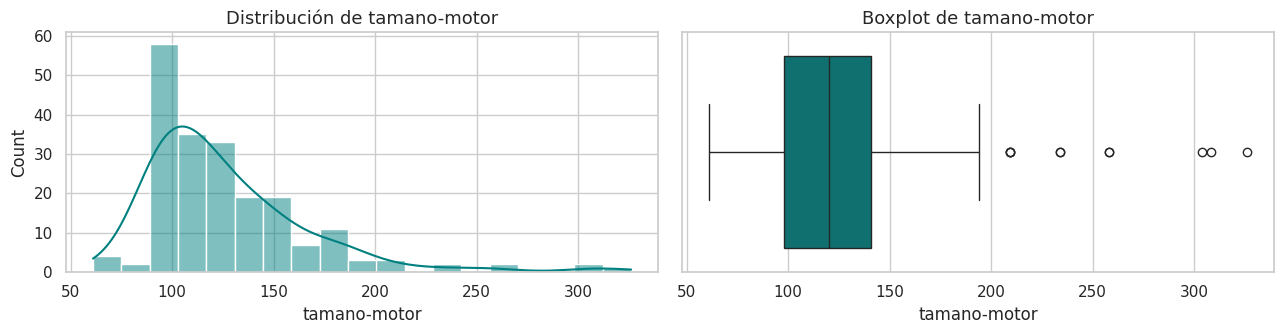


===== caballos-fuerza =====
count    201.00
mean     103.41
std       37.37
min       48.00
25%       70.00
50%       95.00
75%      116.00
max      262.00
Name: caballos-fuerza, dtype: float64


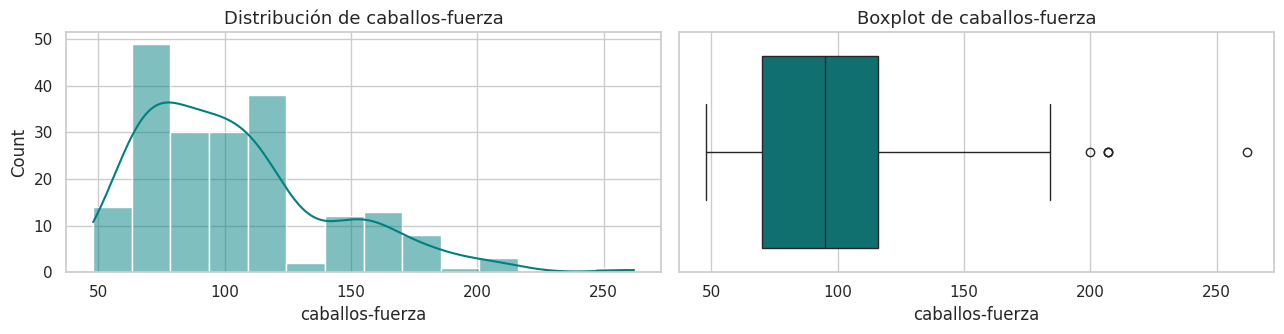


===== peso-vacio =====
count     201.00
mean     2555.67
std       517.30
min      1488.00
25%      2169.00
50%      2414.00
75%      2926.00
max      4066.00
Name: peso-vacio, dtype: float64


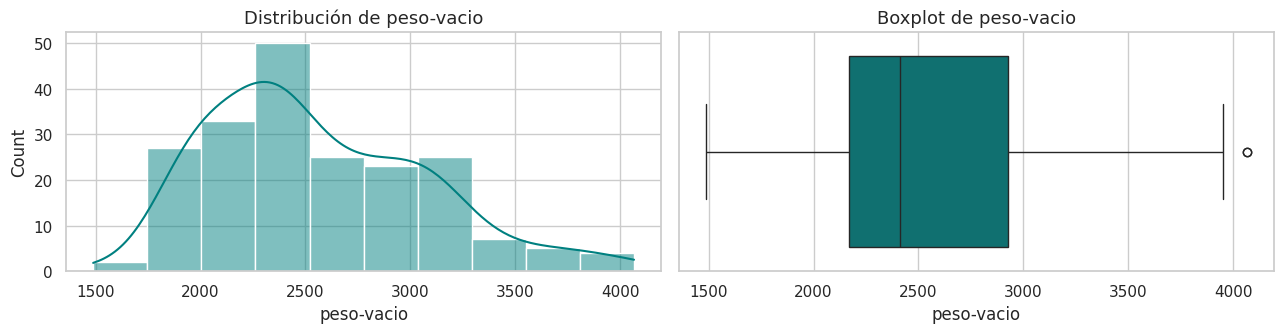


===== millas_por_galon_ciudad =====
count    201.00
mean      25.18
std        6.42
min       13.00
25%       19.00
50%       24.00
75%       30.00
max       49.00
Name: millas_por_galon_ciudad, dtype: float64


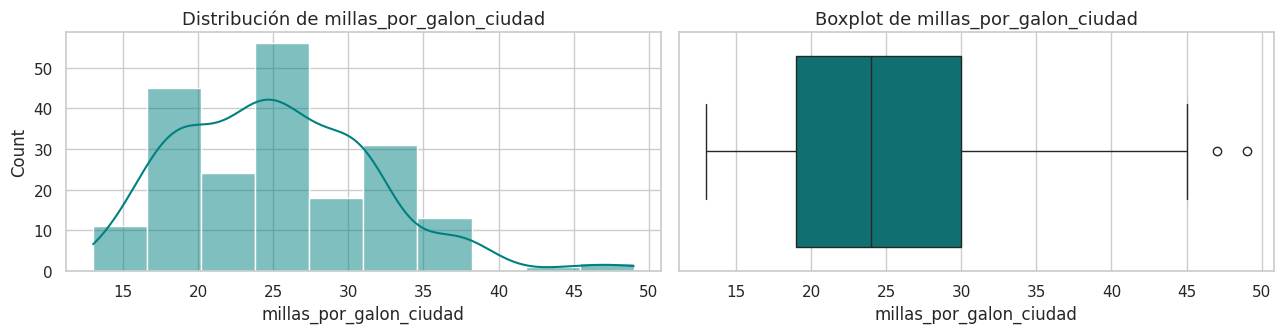

In [19]:
def analizar_variable_continua(columna):
    """Muestra estadísticos, histograma y boxplot de una variable continua."""
    print(f"===== {columna} =====")
    print(df[columna].describe().round(2))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
    sns.histplot(df[columna], kde=True, ax=ax1, color="teal")
    ax1.set_title(f"Distribución de {columna}")
    sns.boxplot(x=df[columna], ax=ax2, color="teal")
    ax2.set_title(f"Boxplot de {columna}")
    plt.tight_layout()
    plt.show()
    print()

# Analizamos las cuatro variables continuas de mayor expectativa
for col in ["tamano-motor", "caballos-fuerza", "peso-vacio", "millas_por_galon_ciudad"]:
    analizar_variable_continua(col)

**Interpretación de las variables continuas.**

- **`tamano-motor`:** distribución sesgada a la derecha, con motores pequeños predominantes y algunos motores grandes que actúan como outliers. Es una candidata sólida a explicar el precio.
- **`caballos-fuerza`:** patrón similar; la mayoría de vehículos se ubican en potencias moderadas, con una cola de alta potencia.
- **`peso-vacio`:** distribución más simétrica, aunque también con vehículos notablemente pesados.
- **`millas_por_galon_ciudad`:** ligera asimetría; los vehículos muy eficientes (mpg alto) constituyen la cola derecha.

En todos los casos, los **outliers superiores** corresponden probablemente a vehículos de gama alta, coherentes con la cola de precios altos observada en la variable objetivo.

### 6.2.1. Cuantificación de outliers mediante el rango intercuartílico (IQR)

El boxplot identifica visualmente los outliers. Para cuantificarlos formalmente empleamos la **regla del IQR**: se consideran atípicos los valores por debajo de `Q1 − 1.5·IQR` o por encima de `Q3 + 1.5·IQR`.

In [20]:
def contar_outliers_iqr(columna):
    """Cuenta los outliers de una columna según la regla del IQR."""
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return len(outliers)

# Resumen de outliers para las principales variables continuas
resumen_outliers = pd.DataFrame({
    "variable": ["precio", "tamano-motor", "caballos-fuerza", "peso-vacio",
                 "millas_por_galon_ciudad", "relacion-compresion"],
})
resumen_outliers["num_outliers"] = resumen_outliers["variable"].apply(contar_outliers_iqr)
resumen_outliers

,variable,num_outliers
0,precio,14
1,tamano-motor,10
2,caballos-fuerza,5
3,peso-vacio,2
4,millas_por_galon_ciudad,2
5,relacion-compresion,27


**Nota metodológica.** La detección de outliers **no implica** su eliminación automática. Como advierte la presentación, muchos de estos valores son **genuinos**: un vehículo deportivo de 288 HP no es un error, es un producto real del portafolio. La decisión de tratarlos se toma en la etapa de modelado y en función del objetivo de negocio.

## 6.3. Variables categóricas

Para las variables categóricas, el análisis univariado consiste en examinar **qué categorías existen** y **con qué frecuencia** aparecen. Utilizamos gráficos de barras. Analizamos las de mayor expectativa: `fabricante`, `traccion`, `estilo-carroceria` y `num-cilindros`.

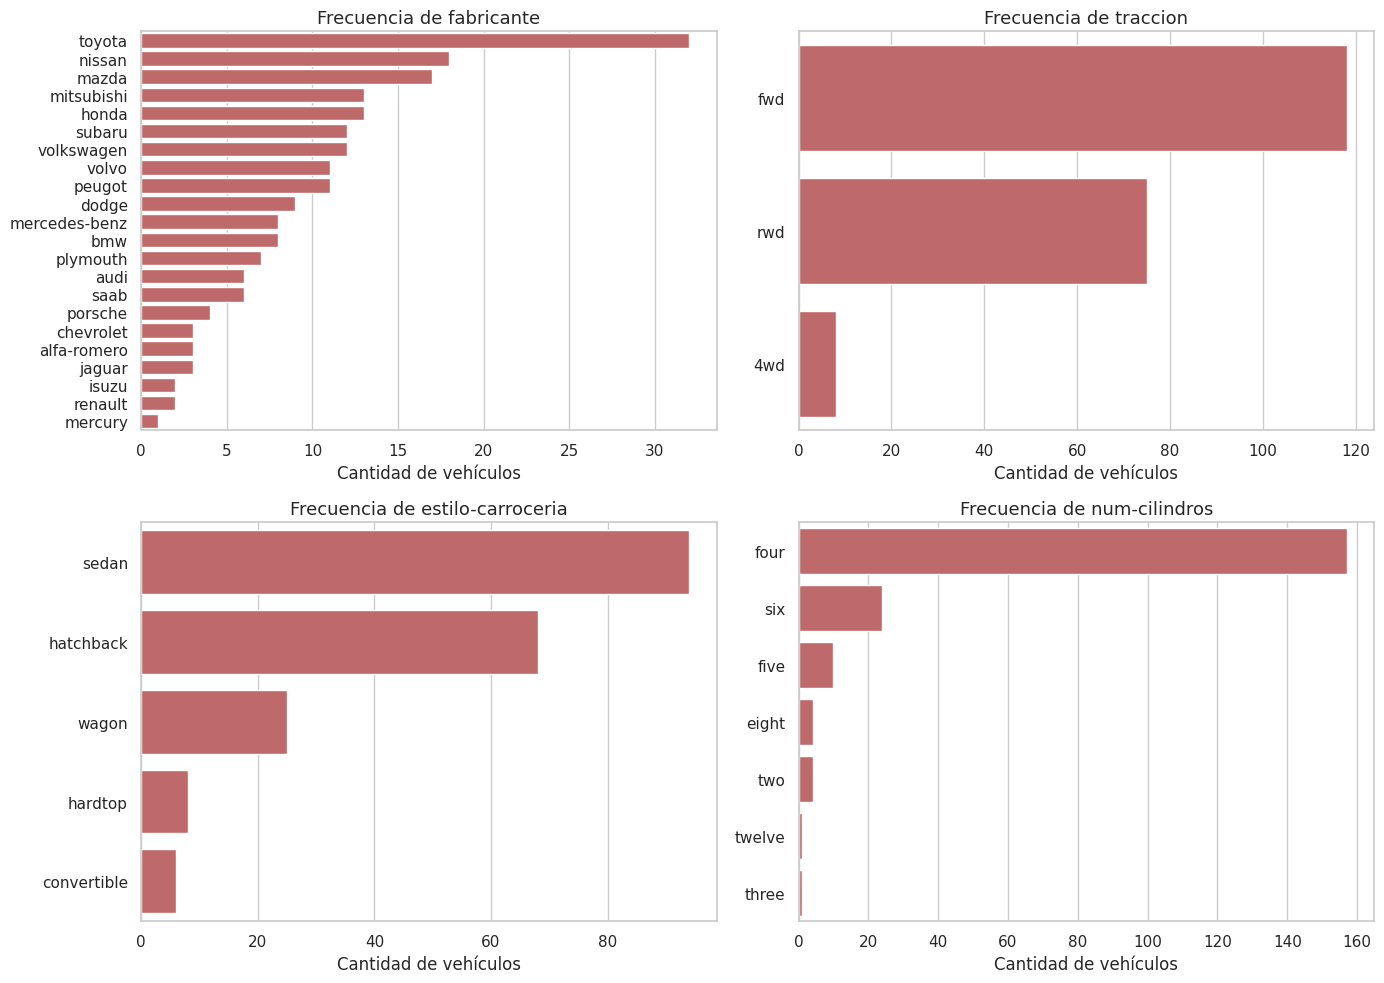

In [21]:
def analizar_variable_categorica(columna, ax):
    """Grafica la frecuencia de cada categoría de una variable."""
    orden = df[columna].value_counts().index
    sns.countplot(y=df[columna], order=orden, ax=ax, color="indianred")
    ax.set_title(f"Frecuencia de {columna}")
    ax.set_xlabel("Cantidad de vehículos")
    ax.set_ylabel("")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ["fabricante", "traccion", "estilo-carroceria", "num-cilindros"]):
    analizar_variable_categorica(col, ax)
plt.tight_layout()
plt.show()

In [22]:
# Tablas de frecuencia detalladas para las variables categóricas clave.
for col in ["traccion", "estilo-carroceria", "num-cilindros"]:
    print(f"----- {col} -----")
    print(df[col].value_counts())
    print()

----- traccion -----
traccion
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

----- estilo-carroceria -----
estilo-carroceria
sedan          94
hatchback      68
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

----- num-cilindros -----
num-cilindros
four      157
six        24
five       10
eight       4
two         4
twelve      1
three       1
Name: count, dtype: int64



**Interpretación de las variables categóricas.**

- **`fabricante`:** el portafolio está dominado por marcas como Toyota, Nissan, Mazda y Honda. Algunas marcas tienen muy pocos registros, lo que limitará la fiabilidad de las conclusiones a nivel de marca individual.
- **`traccion`:** predomina la tracción delantera (**fwd**), seguida de la trasera (**rwd**); la integral (**4wd**) es minoritaria. Se anticipa que **rwd** se asocie a vehículos más costosos.
- **`estilo-carroceria`:** el **sedan** y el **hatchback** son las carrocerías más comunes.
- **`num-cilindros`:** la gran mayoría de vehículos tienen **cuatro cilindros**; las configuraciones de seis o más son escasas y probablemente correspondan a gamas altas.

El desbalance en varias categorías (por ejemplo, muy pocos vehículos de ocho o doce cilindros) es un hallazgo relevante: cualquier conclusión sobre esos grupos se basará en **muy pocas observaciones**.

---
# 7. Análisis bivariado

> *Etapa del flujo: **Análisis bivariado***

El análisis bivariado estudia la **relación entre dos variables**. Es el corazón de nuestra investigación, pues aquí examinamos directamente cómo se relaciona cada atributo con la variable objetivo **precio**, contrastando así las hipótesis planteadas al inicio.

Según los tipos de variables involucradas, empleamos técnicas distintas:

- **Continua vs. continua:** diagramas de dispersión y coeficiente de correlación.
- **Categórica vs. continua:** boxplots comparativos por categoría.

## 7.1. Continua vs. continua: matriz de correlación

Comenzamos con una **matriz de correlación** que resume, en un solo gráfico, la fuerza de la relación lineal entre todas las variables numéricas y el precio.

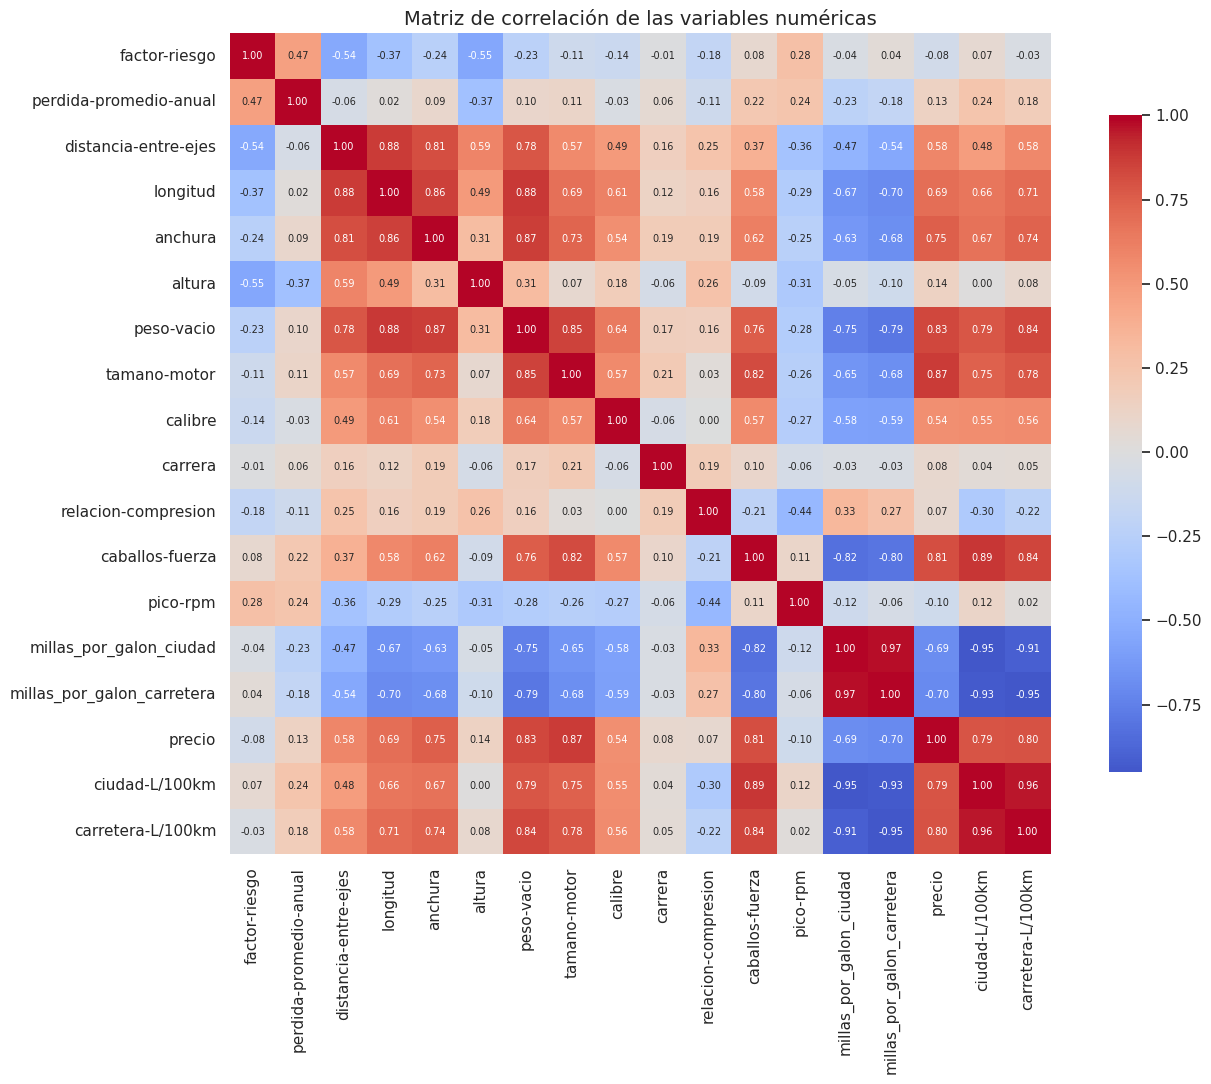

In [23]:
# Matriz de correlación de Pearson entre variables numéricas.
plt.figure(figsize=(14, 11))
corr = df[variables_numericas].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
plt.title("Matriz de correlación de las variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# Extraemos y ordenamos la correlación de cada variable con el PRECIO.
correlacion_precio = corr["precio"].drop("precio").sort_values(ascending=False)
print("Correlación de cada variable numérica con el PRECIO:\n")
print(correlacion_precio.round(3))

Correlación de cada variable numérica con el PRECIO:

tamano-motor                  0.872
peso-vacio                    0.834
caballos-fuerza               0.810
carretera-L/100km             0.801
ciudad-L/100km                0.790
anchura                       0.751
longitud                      0.691
distancia-entre-ejes          0.585
calibre                       0.543
altura                        0.135
perdida-promedio-anual        0.134
carrera                       0.082
relacion-compresion           0.071
factor-riesgo                -0.082
pico-rpm                     -0.102
millas_por_galon_ciudad      -0.687
millas_por_galon_carretera   -0.705
Name: precio, dtype: float64


**Interpretación de la correlación con el precio.** Las variables con correlación positiva más fuerte son, típicamente, el **tamaño del motor**, la **potencia (caballos-fuerza)**, el **peso en vacío**, la **anchura** y la **longitud**. En el extremo opuesto, las variables de **eficiencia en mpg** muestran correlación **negativa** con el precio: los vehículos más costosos consumen más combustible (menos mpg).

Esto ofrece un **primer respaldo cuantitativo** a nuestras hipótesis H1, H2 y H3.

## 7.2. Continua vs. continua: diagramas de dispersión

La correlación resume la relación en un número, pero el **diagrama de dispersión** permite observar su forma. Graficamos las tres variables continuas más correlacionadas con el precio.

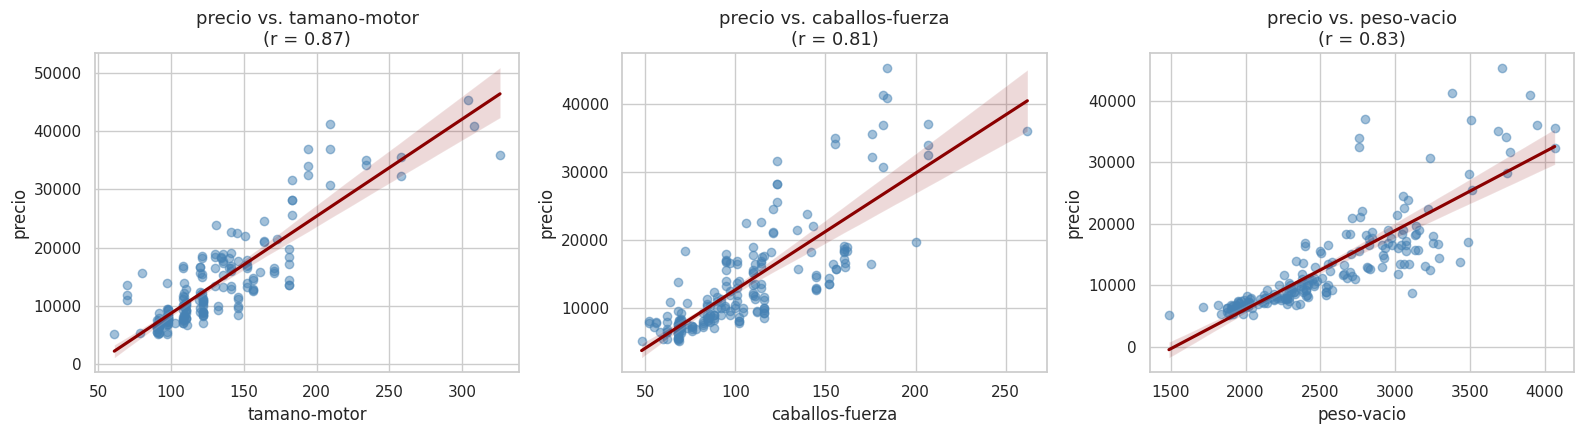

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ["tamano-motor", "caballos-fuerza", "peso-vacio"]):
    sns.regplot(data=df, x=col, y="precio", ax=ax,
                scatter_kws={"alpha": 0.5, "color": "steelblue"},
                line_kws={"color": "darkred"})
    r = df[col].corr(df["precio"])
    ax.set_title(f"precio vs. {col}\n(r = {r:.2f})")

plt.tight_layout()
plt.show()

**Interpretación.** Las tres relaciones son claramente **positivas y aproximadamente lineales**: a mayor tamaño de motor, potencia o peso, mayor precio. La línea de regresión (roja) confirma la tendencia ascendente. Esto **valida las hipótesis H1 y H2**.

## 7.3. Categórica vs. continua: precio según categorías

Para las variables categóricas, comparamos la distribución del precio **dentro de cada categoría** mediante boxplots. Analizamos `traccion`, `num-cilindros` y `fabricante`.

/tmp/ipykernel_1408/3430970241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="traccion", y="precio", order=orden_traccion, palette="Set2")


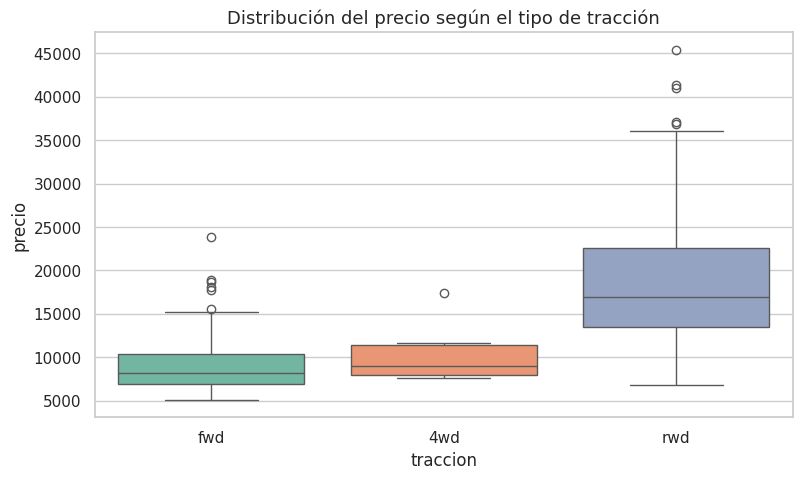

/tmp/ipykernel_1408/3430970241.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="num-cilindros", y="precio", order=orden_cil, palette="Set3")


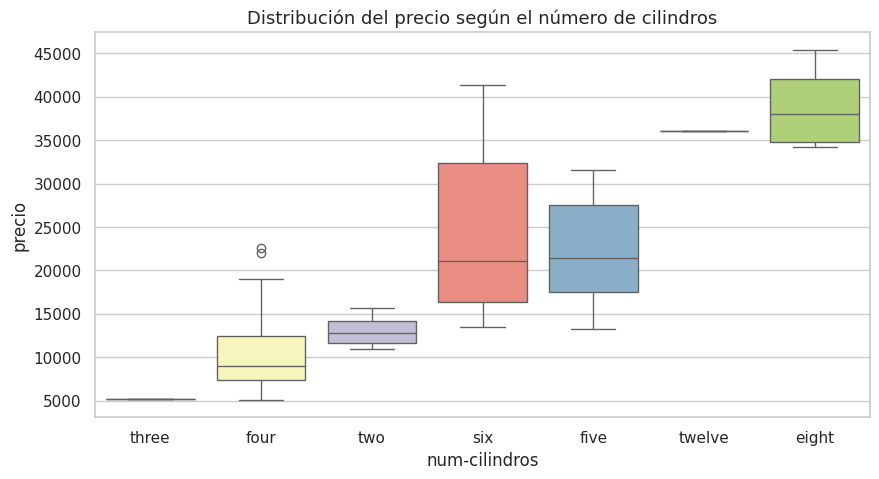

In [26]:
# Precio según tipo de tracción
plt.figure(figsize=(9, 5))
orden_traccion = df.groupby("traccion")["precio"].median().sort_values().index
sns.boxplot(data=df, x="traccion", y="precio", order=orden_traccion, palette="Set2")
plt.title("Distribución del precio según el tipo de tracción")
plt.show()

# Precio según número de cilindros
plt.figure(figsize=(10, 5))
orden_cil = df.groupby("num-cilindros")["precio"].median().sort_values().index
sns.boxplot(data=df, x="num-cilindros", y="precio", order=orden_cil, palette="Set3")
plt.title("Distribución del precio según el número de cilindros")
plt.show()

/tmp/ipykernel_1408/2325562125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fabricante", y="precio", order=orden_fab, palette="viridis")


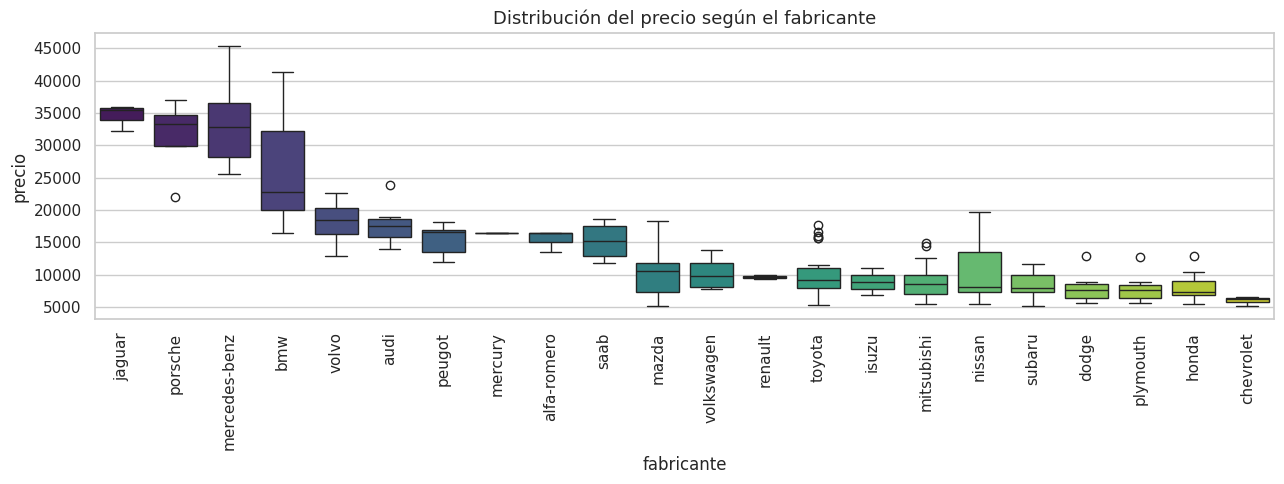

In [27]:
# Precio mediano por fabricante (ordenado)
plt.figure(figsize=(13, 5))
orden_fab = df.groupby("fabricante")["precio"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="fabricante", y="precio", order=orden_fab, palette="viridis")
plt.xticks(rotation=90)
plt.title("Distribución del precio según el fabricante")
plt.tight_layout()
plt.show()

**Interpretación del análisis categórico.**

- **`traccion`:** los vehículos con tracción trasera (**rwd**) presentan precios **notablemente superiores** a los de tracción delantera (**fwd**). Esto **confirma parte de H4**.
- **`num-cilindros`:** existe una relación creciente clara entre el número de cilindros y el precio. Los vehículos de ocho o más cilindros son los más costosos, aunque —como advertimos en el univariado— se basan en **pocas observaciones**.
- **`fabricante`:** marcas como Jaguar, Mercedes-Benz, BMW y Porsche encabezan los precios, mientras que Chevrolet, Dodge o Honda se ubican en la gama económica. Esto **confirma la otra parte de H4**: el fabricante introduce diferencias sistemáticas de precio.

## 7.4. Verificación de una relación esperada: consumo vs. precio

Finalmente, comprobamos la hipótesis H3 (menor eficiencia asociada a mayor precio) de forma directa.

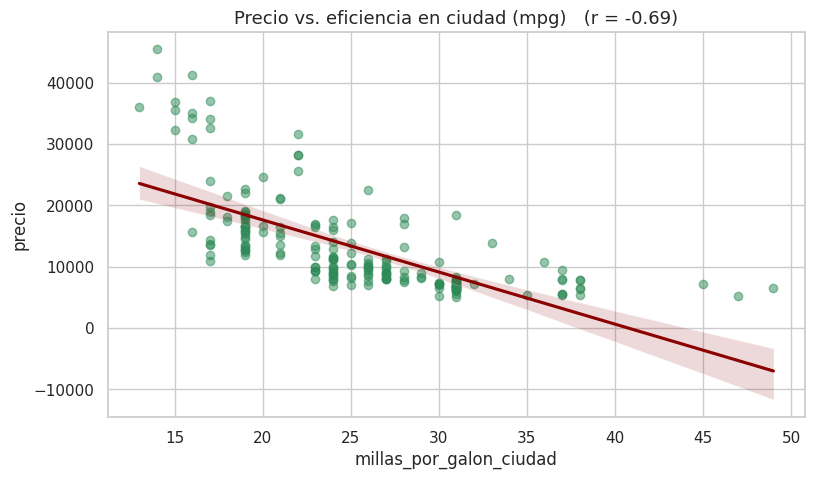

In [28]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x="millas_por_galon_ciudad", y="precio",
            scatter_kws={"alpha": 0.5, "color": "seagreen"},
            line_kws={"color": "darkred"})
r = df["millas_por_galon_ciudad"].corr(df["precio"])
plt.title(f"Precio vs. eficiencia en ciudad (mpg)   (r = {r:.2f})")
plt.show()

**Interpretación.** La relación es **negativa**: a mayor eficiencia (más mpg), menor precio. Los vehículos costosos tienden a ser menos eficientes, lo que **confirma H3**. La causa subyacente es que los vehículos de gama alta suelen montar motores más grandes y potentes, que consumen más combustible.

---
# 8. Conclusiones

> *Etapa del flujo: **Conclusiones***

Recordemos la pregunta que orientó todo el análisis:

> **Pregunta SMART:** *"¿Es posible explicar la variación del precio de los automóviles del portafolio a partir de sus atributos técnicos, utilizando el conjunto de datos histórico disponible?"*

## 8.1. Contraste de las hipótesis

| Hipótesis | Enunciado | Resultado |
|---|---|---|
| **H1** | El tamaño del motor / la potencia se asocian positivamente con el precio. | **Confirmada.** Correlaciones positivas fuertes y relación lineal clara. |
| **H2** | Los vehículos más pesados son más costosos. | **Confirmada.** El peso muestra correlación positiva con el precio. |
| **H3** | Menor eficiencia de combustible se asocia a mayor precio. | **Confirmada.** Correlación negativa entre mpg y precio. |
| **H4** | Fabricante y tracción introducen diferencias de precio. | **Confirmada.** Diferencias claras por marca y por tipo de tracción. |

## 8.2. Sobre la calidad del conjunto de datos

El proceso de EDA permitió establecer que el conjunto de datos es **apto para responder la pregunta SMART**, con base en las siguientes observaciones:

- **Completitud:** tras la limpieza, el dataset quedó **sin valores perdidos**. Los faltantes eran pocos y se trataron con criterios razonables (imputación por media/moda y eliminación de filas sin variable objetivo).
- **Formato:** todas las variables quedaron con el **tipo de dato correcto**, condición indispensable para el análisis y el modelado posterior.
- **Relevancia:** existen **múltiples variables con capacidad explicativa** sobre el precio (tamaño de motor, potencia, peso, cilindros, fabricante, tracción, consumo), lo que respalda la viabilidad de construir posteriormente un modelo predictivo.
- **Tamaño:** el conjunto cuenta con 201 registros útiles. Es **suficiente para un análisis exploratorio**, aunque relativamente pequeño para modelos complejos, lo que conviene tener presente.

## 8.3. Limitaciones y recomendaciones

- **Desbalance en categorías:** algunas categorías (fabricantes con pocos registros, motores de 8/12 cilindros) tienen muy pocas observaciones. Las conclusiones sobre esos grupos deben tomarse con cautela.
- **Outliers legítimos:** los valores atípicos de precio y potencia corresponden a vehículos de gama alta reales; no deben eliminarse sin criterio de negocio.
- **Sesgo del precio:** la variable objetivo está sesgada a la derecha; para el modelado se recomienda evaluar una **transformación logarítmica**.
- **Riesgo de *data leakage*:** las variables `factor-riesgo` y `perdida-promedio-anual` deben revisarse antes del modelado, pues podrían filtrar información no disponible en producción.

## 8.4. Respuesta a la pregunta de negocio

> **El conjunto de datos SÍ contiene información pertinente y de calidad suficiente para explicar el precio de los vehículos.** Los atributos técnicos —en especial el tamaño del motor, la potencia, el peso y el número de cilindros— junto con el fabricante y el tipo de tracción, presentan asociaciones consistentes con el precio. En consecuencia, el negocio puede avanzar con confianza hacia la etapa de **modelado predictivo** del precio, atendiendo las limitaciones señaladas.

---

*Fin de la guía. Este cuaderno reproduce íntegramente el flujo de trabajo del Análisis Exploratorio de Datos presentado en clase: Pregunta SMART → Diccionario → Visión general → Limpieza → Univariado → Bivariado → Conclusiones.*